In [2]:
import geopandas as gpd
import pandas as pd

In [3]:
#inspect format for the geojson
gdf = gpd.read_file('SF_Find_Neighborhoods_20260622.geojson')
gdf.head()

,:id,:version,:created_at,:updated_at,link,name,geometry
0,row-9c9s-nrvx_d2st,rv-ik5x~5ee5~qn5j,2023-10-17 18:16:15.759000+00:00,2023-10-17 18:16:15.759000+00:00,"http://en.wikipedia.org/wiki/Sea_Cliff,_San_Fr...",Seacliff,"MULTIPOLYGON (((-122.49346 37.78352, -122.4937..."
1,row-4aji.3ciw~a9mw,rv-mdai.yzna_8zvm,2023-10-17 18:16:15.759000+00:00,2023-10-17 18:16:15.759000+00:00,,Lake Street,"MULTIPOLYGON (((-122.48715 37.78379, -122.4872..."
2,row-eu9u-w8e2-qrai,rv-i4an.v4q4_iyqi,2023-10-17 18:16:15.759000+00:00,2023-10-17 18:16:15.759000+00:00,http://www.nps.gov/prsf/index.htm,Presidio National Park,"MULTIPOLYGON (((-122.47758 37.81099, -122.4771..."
3,row-i29b~xkzn-zwdm,rv-hqc6-akwq-3vau,2023-10-17 18:16:15.759000+00:00,2023-10-17 18:16:15.759000+00:00,,Presidio Terrace,"MULTIPOLYGON (((-122.47241 37.78735, -122.4710..."
4,row-ct6a~375u-ztve,rv-25k5_pz6i_nf87,2023-10-17 18:16:15.759000+00:00,2023-10-17 18:16:15.759000+00:00,http://www.sfgate.com/neighborhoods/sf/innerri...,Inner Richmond,"MULTIPOLYGON (((-122.47263 37.78631, -122.4668..."


<Axes: >

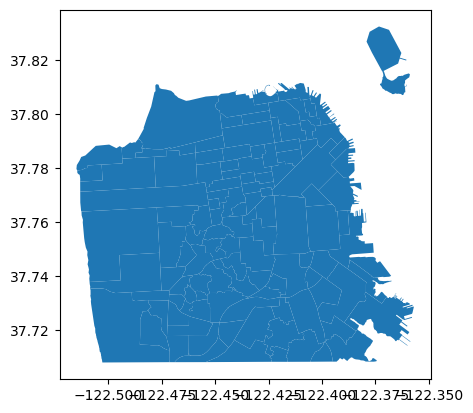

In [ ]:
#make sure it plots! No broken geometries
gdf.plot()

In [5]:
#inspect crs to make sure it's a good one (one we want to work with)
gdf.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [6]:
#drop columns we don't need, assign new id column
neighborhoods = gdf[['name', 'geometry']].copy()
neighborhoods['id'] = range(1,118)
neighborhoods = neighborhoods[['id', 'name', 'geometry']].copy()
neighborhoods.head()

,id,name,geometry
0,1,Seacliff,"MULTIPOLYGON (((-122.49346 37.78352, -122.4937..."
1,2,Lake Street,"MULTIPOLYGON (((-122.48715 37.78379, -122.4872..."
2,3,Presidio National Park,"MULTIPOLYGON (((-122.47758 37.81099, -122.4771..."
3,4,Presidio Terrace,"MULTIPOLYGON (((-122.47241 37.78735, -122.4710..."
4,5,Inner Richmond,"MULTIPOLYGON (((-122.47263 37.78631, -122.4668..."


<Axes: >

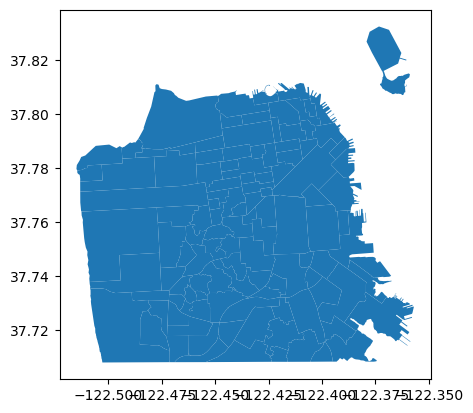

In [7]:
#quick check to make sure we didn't break anything
neighborhoods.plot()

In [8]:
#save in a few formats
neighborhoods.to_file('sf_find_neighborhoods_processed.geojson')
neighborhoods.to_csv('sf_find_neighborhoods_processed.csv', index=False)